# Análisis Estratégico de Revenue y Cancelaciones — Industria Hotelera

## 1. Contexto del negocio
Este proyecto analiza 119,390 reservas reales de dos hoteles portugueses:
- **City Hotel** — ubicado en Lisboa, capital de Portugal. Perfil urbano con 
  alta demanda de viajeros de negocios y turismo urbano.

- **Resort Hotel** — ubicado en el Algarve, región costera del sur de Portugal. 
  Perfil vacacional con demanda estacional concentrada en verano.

- **Época** Los datos cubren el período 2015-2017 e incluyen información de reservas, 
cancelaciones, tarifas y perfil de clientes.

**Preguntas de negocio:**
1. ¿Cuáles son los patrones de cancelación y qué perfil de cliente cancela más?
2. ¿Cómo varía el revenue por temporada, tipo de hotel y segmento de mercado?
3. ¿Qué canales de distribución son más rentables y cuáles generan más cancelaciones?
4. ¿Qué oportunidades concretas tiene el hotel para mejorar su rentabilidad?

## 2. Estructura del análisis

Este proyecto está organizado en seis fases progresivas:

**Fase 1 — Limpieza y preparación de datos**
Tratamiento de nulos, corrección de tipos de datos y creación de variables derivadas para enriquecer el análisis.

**Fase 2 — Análisis Exploratorio (EDA)**
Exploración de patrones de reservas, cancelaciones, revenue y canales de distribución a través de cuatro bloques analíticos con visualizaciones interactivas.

**Fase 3 — Análisis de cancelaciones**
Identificación del perfil de cliente de alto riesgo de cancelación y 
cuantificación del impacto económico para el negocio.

**Fase 4 — Revenue Analysis**
Cálculo de métricas hoteleras reales (ADR, RevPAR) y análisis de oportunidades de optimización de ingresos por temporada y segmento.

**Fase 5 — Análisis SQL**
Consultas sobre base de datos relacional para responder preguntas de negocio clave y validar hallazgos del análisis en Python.

**Fase 6 — Conclusiones y recomendaciones**
Ficha ejecutiva con hallazgos principales, impacto estimado y plan de acción concreto para la gerencia hotelera.

## 3. Diccionario de Datos:

## Diccionario de datos

| Variable | Descripción |
|---|---|
| `hotel` | Tipo de hotel: City Hotel (Lisboa) o Resort Hotel (Algarve) |
| `is_canceled` | Reserva cancelada: 1 = sí, 0 = no |
| `lead_time` | Días de anticipación entre la reserva y la llegada |
| `arrival_date_year` | Año de llegada |
| `arrival_date_month` | Mes de llegada |
| `arrival_date_week_number` | Semana del año de llegada |
| `arrival_date_day_of_month` | Día del mes de llegada |
| `stays_in_weekend_nights` | Noches de fin de semana en la estadía |
| `stays_in_week_nights` | Noches entre semana en la estadía |
| `adults` | Número de adultos |
| `children` | Número de niños |
| `babies` | Número de bebés |
| `meal` | Tipo de plan de comidas: BB, HB, FB, SC |
| `country` | País de origen del huésped |
| `market_segment` | Segmento de mercado: Direct, Corporate, Online TA, etc. |
| `distribution_channel` | Canal de distribución: Direct, TA/TO, Corporate, GDS |
| `is_repeated_guest` | Huésped repetido: 1 = sí, 0 = no |
| `previous_cancellations` | Cancelaciones previas del huésped |
| `previous_bookings_not_canceled` | Reservas previas no canceladas |
| `reserved_room_type` | Tipo de habitación reservada |
| `assigned_room_type` | Tipo de habitación asignada al llegar |
| `booking_changes` | Número de modificaciones a la reserva |
| `deposit_type` | Tipo de depósito: No Deposit, Non Refund, Refundable |
| `agent` | ID del agente de viajes, "Direct" si reserva directa |
| `days_in_waiting_list` | Días en lista de espera antes de confirmar |
| `customer_type` | Tipo de cliente: Transient, Contract, Group, Transient-Party |
| `adr` | Tarifa diaria promedio en euros |
| `required_car_parking_spaces` | Espacios de parqueo requeridos |
| `total_of_special_requests` | Número de solicitudes especiales del huésped |
| `reservation_status` | Estado final: Check-Out, Canceled, No-Show |
| `reservation_status_date` | Fecha del último estado de la reserva |
| `total_nights` | Total de noches de estadía (calculado) |
| `arrival_date` | Fecha completa de llegada (calculada) |


In [121]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3


In [ ]:

# Configuración visual general
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Librerías cargadas correctamente ✓")

In [8]:
df = pd.read_csv(r"C:/Users/mateg/Documents/triple_ten/hotels/data/hotel_bookings.csv")

In [9]:
df.shape

(119390, 32)

In [10]:
print(df.head)

<bound method NDFrame.head of                hotel  is_canceled  lead_time  arrival_date_year  \
0       Resort Hotel            0        342               2015   
1       Resort Hotel            0        737               2015   
2       Resort Hotel            0          7               2015   
3       Resort Hotel            0         13               2015   
4       Resort Hotel            0         14               2015   
...              ...          ...        ...                ...   
119385    City Hotel            0         23               2017   
119386    City Hotel            0        102               2017   
119387    City Hotel            0         34               2017   
119388    City Hotel            0        109               2017   
119389    City Hotel            0        205               2017   

       arrival_date_month  arrival_date_week_number  \
0                    July                        27   
1                    July                        27   


In [11]:
# Estructura del dataset
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dimensiones: (119390, 32)

Tipos de datos:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                     

## 4. Fase 1 — Limpieza y preparación de datos

En esta fase tratamos los valores nulos, corregimos tipos de datos y creamos 
variables derivadas que serán clave para el análisis de revenue y cancelaciones.

**Decisiones de limpieza:**
- `children`: 4 nulos → se imputan con 0 (sin dato = sin niños)
- `country`: 488 nulos → se imputan con "Unknown"
- `agent`: 16,340 nulos → se imputan con "Direct" (reserva sin agente)
- `company`: 112,593 nulos (94%) → se elimina la columna

**Variables nuevas que crearemos:**
- `total_nights`: noches totales de estadía
- `arrival_date`: fecha completa de llegada

In [13]:
# --- Tratamiento de nulos ---
df['children'] = df['children'].fillna(0).astype(int)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna('Direct').astype(str)
df = df.drop(columns=['company'])

# --- Variables derivadas ---
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)

# --- Verificación ---
print("Nulos restantes:", df.isnull().sum().sum())
print("Shape final:", df.shape)
print("\nNuevas columnas:")
print(df[['total_nights', 'arrival_date']].head())

Nulos restantes: 0
Shape final: (119390, 33)

Nuevas columnas:
   total_nights arrival_date
0             0   2015-07-01
1             0   2015-07-01
2             1   2015-07-01
3             1   2015-07-01
4             2   2015-07-01


In [14]:
# Verificación visual del dataset limpio
print("Tipos de datos actualizados:")
print(df[['children', 'agent', 'total_nights', 'arrival_date']].dtypes)
print("\nEstadísticas básicas de columnas clave:")
df[['lead_time', 'total_nights', 'adr', 'is_canceled']].describe()

Tipos de datos actualizados:
children                 int64
agent                      str
total_nights             int64
arrival_date    datetime64[us]
dtype: object

Estadísticas básicas de columnas clave:


,lead_time,total_nights,adr,is_canceled
count,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,3.427900,101.831122,0.370416
std,106.863097,2.557439,50.535790,0.482918
min,0.000000,0.000000,-6.380000,0.000000
25%,18.000000,2.000000,69.290000,0.000000
50%,69.000000,3.000000,94.575000,0.000000
75%,160.000000,4.000000,126.000000,1.000000
max,737.000000,69.000000,5400.000000,1.000000


### Conclusión Fase 1
El dataset quedó limpio, sin nulos y con variables adicionales listas para el análisis.
Se identificaron valores atípicos en `adr` y `total_nights` que serán tratados en el EDA.

## 5. Fase 2 — Análisis Exploratorio de Datos (EDA)

En esta fase respondemos las preguntas de negocio a través de visualizaciones 
y análisis estadístico. El análisis está organizado en cuatro bloques:

1. Perfil general de reservas
2. Análisis de cancelaciones
3. Análisis de revenue (ADR)
4. Canales de distribución y segmentos de mercado

### Bloque 1 — Perfil general de reservas

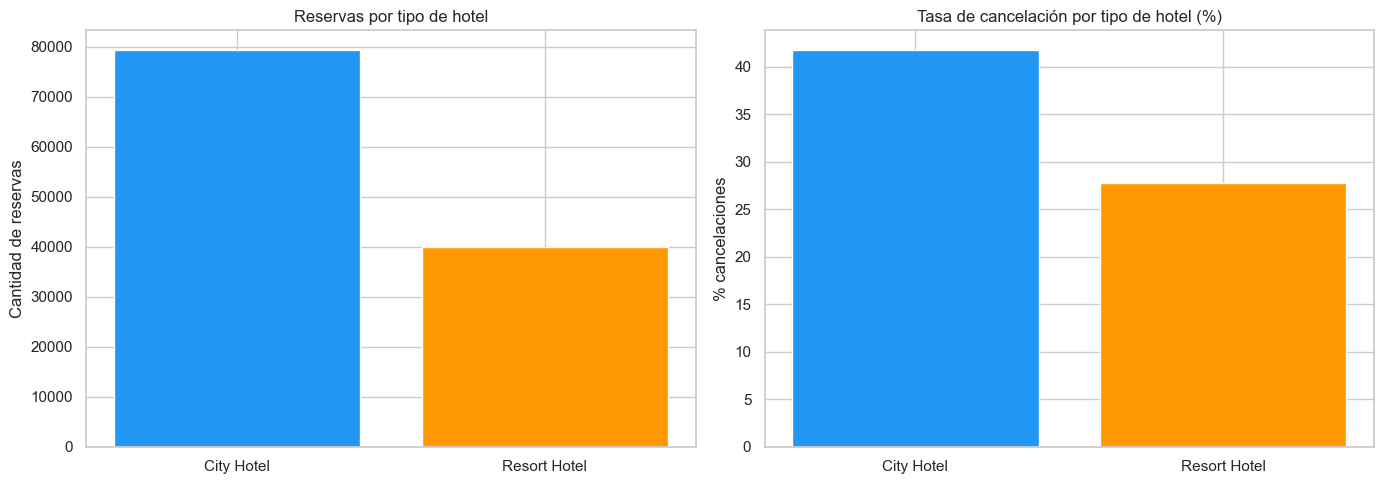


Reservas por hotel:
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

Tasa de cancelación:
hotel
City Hotel      41.7
Resort Hotel    27.8
Name: is_canceled, dtype: float64


In [15]:
# Distribución de reservas por tipo de hotel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1 — Conteo por tipo de hotel
hotel_counts = df['hotel'].value_counts()
axes[0].bar(hotel_counts.index, hotel_counts.values, color=['#2196F3', '#FF9800'])
axes[0].set_title('Reservas por tipo de hotel')
axes[0].set_ylabel('Cantidad de reservas')

# Gráfica 2 — Tasa de cancelación por tipo de hotel
cancel_rate = df.groupby('hotel')['is_canceled'].mean() * 100
axes[1].bar(cancel_rate.index, cancel_rate.values, color=['#2196F3', '#FF9800'])
axes[1].set_title('Tasa de cancelación por tipo de hotel (%)')
axes[1].set_ylabel('% cancelaciones')

plt.tight_layout()
plt.show()

print("\nReservas por hotel:")
print(hotel_counts)
print("\nTasa de cancelación:")
print(cancel_rate.round(1))

### Evolución de reservas en el tiempo

Analizamos cómo varían las reservas mes a mes entre 2015 y 2017 
para identificar patrones de estacionalidad y tendencias de demanda.

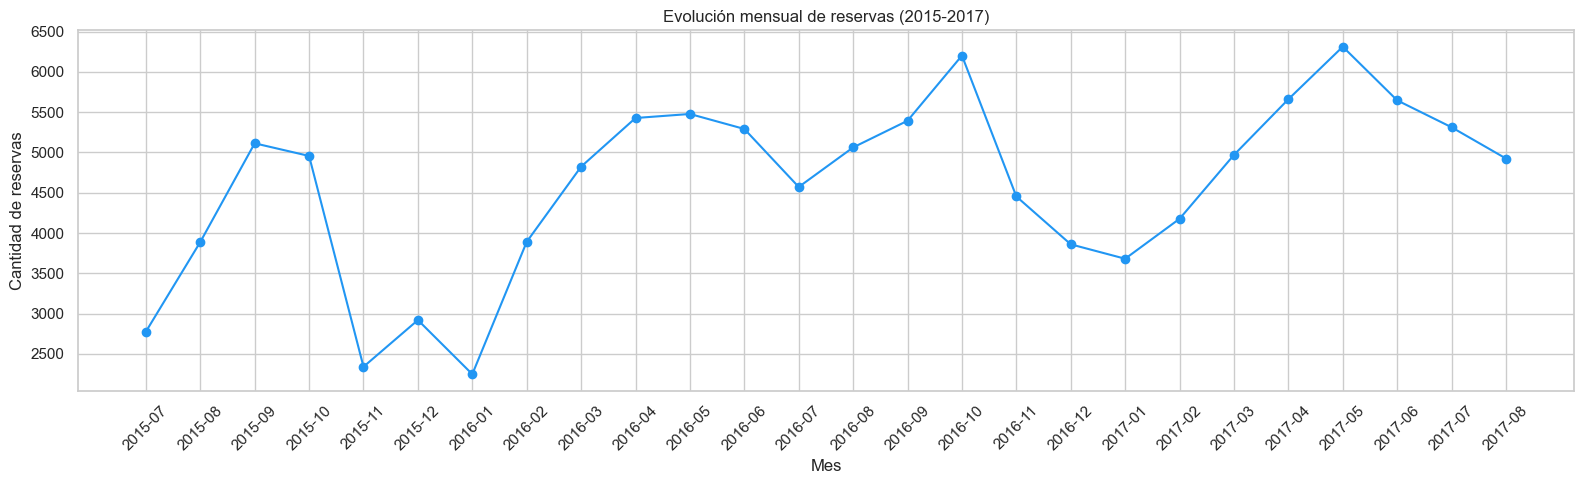

In [28]:
# Evolución mensual usando fecha real
reservas_tiempo = df.groupby(df['arrival_date'].dt.to_period('M'))['hotel'].count()
reservas_tiempo.index = reservas_tiempo.index.astype(str)

plt.figure(figsize=(16, 5))
plt.plot(reservas_tiempo.index, reservas_tiempo.values, marker='o', color='#2196F3')
plt.title('Evolución mensual de reservas (2015-2017)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de reservas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Hallazgos — Evolución de reservas:**
- La demanda creció consistentemente entre 2015 y 2017, indicando un negocio en expansión.
- Se identifican dos temporadas bajas recurrentes: enero y noviembre-diciembre.
- Los picos de demanda ocurren en mayo-junio y octubre.
- La estacionalidad es predecible, lo que permite al hotel anticipar estrategias 
  de pricing y disponibilidad por temporada.

## Fase 3 — Análisis de Cancelaciones

Las cancelaciones representan el **37% de todas las reservas**, con una brecha 
significativa entre el City Hotel (41.7%) y el Resort Hotel (27.8%).

Este bloque busca responder:
- ¿Quién cancela? — perfil del cliente por tipo, segmento y canal
- ¿Cuándo cancela? — anticipación de la reserva y patrones temporales
- ¿Cómo llegó? — canal de distribución y segmento de mercado
- ¿Hay señales de alerta? — depósito, historial de cancelaciones previas

El objetivo es identificar el perfil de cliente de alto riesgo de cancelación 
para que el hotel pueda tomar acciones preventivas.

In [31]:
# Tasa de Cancelación por tipo de cliente

cancel_rate_customer = df.groupby('customer_type')['is_canceled'].mean().round(2)*100
print(cancel_rate_customer)

customer_type
Contract           31.0
Group              10.0
Transient          41.0
Transient-Party    25.0
Name: is_canceled, dtype: float64


In [45]:
# Gráfica interactiva con Plotly
fig = px.bar(
    x=cancel_rate_customer.index,
    y=cancel_rate_customer.values,
    color=cancel_rate_customer.values,
    color_continuous_scale='Bluered',
    title='Tasa de cancelación por tipo de cliente (%)',
    labels={'x': 'Tipo de Cliente', 'y': '% Cancelaciones', 'color': '%'}
)
fig.update_layout(xaxis_tickangle=45)
fig.update_xaxes(categoryorder='total descending')
fig.update_layout(
    xaxis_tickangle=45,
    width=600,
    height=400
)
fig.show()



**Hallazgos — Cancelación por tipo de cliente:**
- Transient (41%) — mayor riesgo, viajero individual sin compromiso contractual.
- Contract (31%) — cancelación alta para ser cliente con acuerdo, revisar penalidades.
- Transient-Party (25%) — más estable que Transient por coordinación grupal.
- Group (10%) — el más estable, planificación previa reduce cancelaciones.

**Acción recomendada:** enfocar políticas de cancelación en segmento Transient —
tarifas no reembolsables o depósitos obligatorios para reservas anticipadas.

In [ ]:
# Tasa de Cancelación por Segmento de Mercado

cancel_rate_segment = df.groupby('market_segment')['is_canceled'].mean().round(2)*100
print(cancel_rate_segment)


market_segment
Aviation          22.0
Complementary     13.0
Corporate         19.0
Direct            15.0
Groups            61.0
Offline TA/TO     34.0
Online TA         37.0
Undefined        100.0
Name: is_canceled, dtype: float64


In [40]:
# Gráfica interactiva con Plotly
fig = px.bar(
    x=cancel_rate_segment.index,
    y=cancel_rate_segment.values,
    color=cancel_rate_segment.values,
    color_continuous_scale='RdYlGn_r',
    title='Tasa de cancelación por segmento de mercado (%)',
    labels={'x': 'Segmento', 'y': '% Cancelaciones', 'color': '%'}
)
fig.update_layout(xaxis_tickangle=45)
fig.update_xaxes(categoryorder='total descending')
fig.show()


**Hallazgos — Cancelación por segmento de mercado:**
- Undefined (100%) — registros sin segmento, errores de datos, se excluyen del análisis.
- Groups (61%) — alta tasa por reservas tentativas que bloquean habitaciones y se cancelan parcialmente.
- Online TA (37%) — segmento crítico: combina alto volumen con alta cancelación (Booking, Expedia).
- Offline TA/TO (34%) — agencias tradicionales, cancelación alta pero menor volumen.
- Direct (15%) — el más estable, cliente con mayor compromiso al reservar directamente.

**Acción recomendada:** priorizar estrategias de retención en Online TA — 
tarifas no reembolsables con descuento y beneficios exclusivos para reserva directa.

In [46]:
# Tasa de Cancelación por Canal de Distribución

cancel_rate_channel = df.groupby('distribution_channel')['is_canceled'].mean().round(2)*100
print(cancel_rate_channel)


distribution_channel
Corporate    22.0
Direct       17.0
GDS          19.0
TA/TO        41.0
Undefined    80.0
Name: is_canceled, dtype: float64


In [48]:
# Gráfica interactiva con Plotly
fig = px.bar(
    x=cancel_rate_channel.index,
    y=cancel_rate_channel.values,
    color=cancel_rate_channel.values,
    color_continuous_scale='Plasma',
    title='Tasa de cancelación por Canal de Distribución (%)',
    labels={'x': 'Canal', 'y': '% Cancelaciones', 'color': '%'}
)
fig.update_layout(xaxis_tickangle=45)
fig.update_xaxes(categoryorder='total descending')
fig.show()


Hallazgo clave: el canal TA/TO concentra el mayor riesgo real de cancelación, lo que es consistente con el hallazgo de Online TA en el segmento de mercado. Los intermediarios generan más cancelaciones que los canales directos.

In [ ]:
# Distribución de la variable Lead_time (Días de anticipación entre la reserva y la llegada)

print(df['lead_time'].describe())

count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64


In [51]:
fig = px.box(df, y='lead_time', title='Distribución de Lead Time')
fig.show()

Interpretación:

25% reserva con menos de 18 días
50% reserva entre 18 y 160 días
25% reserva con más de 160 días

### Análisis de cancelaciones por anticipación de reserva (Lead Time)

Para analizar la relación entre anticipación y cancelación, agrupamos el lead time en rangos:

- **0-7 días** — reserva de última hora
- **8-30 días** — reserva de corto plazo
- **31-90 días** — reserva de mediano plazo
- **91-180 días** — reserva anticipada
- **181+ días** — reserva muy anticipada

In [ ]:
# Definición de Rangos y creación de columna lead_time_range

df['lead_time_range'] = pd.cut(df['lead_time'], bins=[0, 7, 30, 90, 180, 737], labels=['0-7', '8-30', '31-90', '91-180', '181+'])

In [56]:
# Tasa de cancelación por rago

cancel_rate_lead = df.groupby('lead_time_range')['is_canceled'].mean().round(2)*100
print(cancel_rate_lead)

lead_time_range
0-7       11.0
8-30      28.0
31-90     38.0
91-180    45.0
181+      57.0
Name: is_canceled, dtype: float64


 Última hora (0-7 días) — 11% cancela, casi nadie
Corto plazo (8-30 días) — 28%
Mediano plazo (31-90 días) — 38%
Anticipada (91-180 días) — 45%
Muy anticipada (181+) — 57% cancela, más de la mitad
 

In [59]:
# Gráfica interactiva con Plotly
fig = px.line(
    x=cancel_rate_lead.index.astype(str),
    y=cancel_rate_lead.values,
    markers=True,
    title='Tasa de cancelación según anticipación de reserva (%)',
    labels={'x': 'Anticipación', 'y': '% Cancelaciones'}
)
fig.update_traces(line_color='#7C3AED', marker=dict(size=10))
fig.show()

Interpretación: a mayor anticipación de reserva, mayor tasa de cancelación. Relación directamente proporcional confirmada con datos.

**Hallazgos — Cancelación por anticipación de reserva (Lead Time):**
- Última hora (0-7 días) — 11% cancela, casi nadie
- Corto plazo (8-30 días) — 28%
- Mediano plazo (31-90 días) — 38%
- Anticipada (91-180 días) — 45%
- Muy anticipada (181+) — 57% cancela, más de la mitad

**Acción recomendada:** aplicar políticas de depósito obligatorio o tarifas 
no reembolsables para reservas con más de 90 días de anticipación.

In [62]:
# Definición de segmentos de cancelación previa y creación de columna previous_cancellations

df['prev_cancel_segment'] = pd.cut(df['previous_cancellations'], bins=[-1,0, 1, 26], labels=['0 cancelaciones','1 cancelacion', '2+ cancelaciones'])

In [65]:
cancel_rate_prev = df.groupby('prev_cancel_segment')['is_canceled'].mean().round(2)*100
print(cancel_rate_prev)

prev_cancel_segment
0 cancelaciones     34.0
1 cancelacion       94.0
2+ cancelaciones    53.0
Name: is_canceled, dtype: float64


In [66]:
fig = px.bar(
    x=cancel_rate_prev.values,
    y=cancel_rate_prev.index.astype(str),
    orientation='h',
    color=cancel_rate_prev.values,
    color_continuous_scale='RdYlGn_r',
    title='Tasa de cancelación según historial de cancelaciones previas (%)',
    labels={'x': '% Cancelaciones', 'y': 'Historial'}
)
fig.show()

De los clientes con 0 cancelaciones previas,  → 34% canceló

De los clientes con 1 cancelación previa,  → 94% canceló
De los clientes con 2+ cancelaciones previas, → 53% canceló
el hotel puede identificar estos clientes en el momento de la reserva y aplicar políticas específicas antes de que cancelen.

deposit_type` | Tipo de depósito: No Deposit, Non Refund, Refundable |

In [ ]:
# Tasa de cancelación por tipo de depósito

deposit_type_cancel = df.groupby('deposit_type')['is_canceled'].mean().round(2)*100
print(deposit_type_cancel)

deposit_type
No Deposit    28.0
Non Refund    99.0
Refundable    22.0
Name: is_canceled, dtype: float64


In [77]:
# Gráfica interactiva con Plotly
fig = px.bar(
    x=deposit_type_cancel.values,
    y=deposit_type_cancel.index.astype(str),
    color=deposit_type_cancel.values,
    color_continuous_scale='Plasma',
    title='Tasa de cancelación por tipo de depósito (%)',
    labels={'x': '% Cancelaciones', 'y': 'Tipo de depósito', 'color': '%'},
    orientation='h'
)
fig.show()


**Hallazgos — Cancelación por tipo de depósito:**
- No Deposit (28%) — sin depósito, cancelación moderada. El hotel no cobra nada si cancela.
- Refundable (22%) — el más estable, cliente con mayor compromiso.
- Non Refund (99%) — casi el 100% cancela, pero el hotel ya cobró el depósito.

**Implicación de negocio:** aunque el 99% de las reservas Non Refund terminan en cancelación, el hotel no pierde dinero porque ya cobró el depósito y no lo devuelve. 

El verdadero riesgo financiero está en No Deposit — cuando ese cliente cancela, 
el hotel queda con la habitación vacía sin haber recibido ningún pago. 
Por eso la prioridad no es eliminar cancelaciones Non Refund, sino reducir 
la exposición a reservas sin depósito, especialmente en temporada alta.


## Perfil del cliente de alto riesgo de cancelación

Un cliente representa alto riesgo de cancelación cuando combina estas características:

- **Tipo:** Transient — viajero individual sin compromiso contractual
- **Canal de origen:** Online TA (Booking, Expedia) o TA/TO — intermediarios digitales
- **Anticipación:** más de 90 días entre la reserva y la llegada
- **Depósito:** sin depósito (No Deposit) — sin costo económico por cancelar
- **Historial:** al menos una cancelación previa registrada (94% vuelve a cancelar)

**Conclusión:** el perfil de mayor riesgo es un viajero individual que reservó 
con más de 90 días de anticipación a través de una OTA, sin depósito y con 
historial de cancelaciones previas. Este cliente debe activar automáticamente 
políticas de retención: depósito obligatorio, tarifa no reembolsable con descuento 
o comunicación proactiva de beneficios por mantener la reserva.

## Fase 4 — Revenue Analysis

El revenue en hotelería se mide principalmente con dos métricas:

- ADR (Average Daily Rate) — tarifa promedio por noche, ya la tenemos en la    columna adr
- RevPAR (Revenue Per Available Room) — ingresos por habitación disponible, esta la calculamos nosotros.

Cálculo de métricas hoteleras reales (ADR, RevPAR) y análisis de oportunidades 
de optimización de ingresos por temporada y segmento.

**Pregunta central:** ¿dónde está ganando y dónde está dejando de ganar dinero el hotel?

**Para responderla analizaremos:**
- ADR por tipo de hotel
- ADR por temporada
- ADR por segmento de mercado
- Impacto de las cancelaciones en el revenue

In [ ]:
# analizamos primero las estadísticas de la columna 'adr'

print(df['adr'].describe())

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64


# revisamos los valores min y máx

Min = -6.38 — una tarifa negativa no tiene sentido, son errores de datos
Max = 5,400 — outlier extremo, una noche a 5,400 euros distorsiona el promedio

Antes de calcular el ADR por hotel vamos a filtrar estos valores atípicos.

In [81]:
# generamos boxplot  de columna 'adr' 

fig = px.box(df, y='adr', title='Distribución de ADR (tarifa diaria promedio)')
fig.show()

toda la distribución real está comprimida abajo cerca de 0-200, y ese único punto a 5,400 es claramente un outlier extremo que distorsiona la escala completa.
Ahora filtramos y creamos un dataframe limpio para el análisis de revenue:

In [ ]:
df_revenue = df[(df['adr'] > 0) & (df['adr'] < 500)]
print("Registros originales:", len(df))
print("Registros después del filtro:", len(df_revenue))
print("Registros eliminados:", len(df) - len(df_revenue))

Registros originales: 119390
Registros después del filtro: 117427
Registros eliminados: 1963


 Los 1,963 registros representan solo el 1.6% del total y son:

Tarifas negativas o cero — errores de registro
Tarifas mayores a 500 euros — outliers extremos que jalan la media hacia arriba artificialmente

Si los dejáramos, el ADR promedio quedaría inflado y las conclusiones de negocio serían incorrectas. Por ejemplo, ese único registro de 5,400 euros por sí solo sube el promedio varios euros.
Con 117,427 registros tenemos más que suficiente para un análisis robusto y confiable.

In [87]:
# Calculamos ADR por tipo de hotel

adr_hotel = df_revenue.groupby('hotel')['adr'].mean().round(2)
print(adr_hotel)

hotel
City Hotel      106.86
Resort Hotel     96.76
Name: adr, dtype: float64


In [88]:
fig = px.funnel(
    x=adr_hotel.values,
    y=adr_hotel.index,
    title='ADR promedio por tipo de hotel (€)',
    labels={'x': 'ADR promedio', 'y': 'Hotel'}
)
fig.show()

**Hallazgos — ADR por tipo de hotel:**
- City Hotel: €106.86/noche — tarifa ~10% superior al Resort Hotel
- Resort Hotel: €96.76/noche — tarifa menor pero perfil de cliente más estable

**Tensión de negocio identificada:**
El City Hotel cobra más por noche pero tiene una tasa de cancelación 
significativamente mayor (41.7% vs 27.8%). Esto significa que su revenue 
potencial se ve más afectado por cancelaciones que el Resort Hotel.

**Próximo análisis:** cuantificar el impacto económico real de esas cancelaciones.

In [ ]:
# Crear columna de temporada

def asignar_temporada(mes):
    if mes in ['June', 'July', 'August', 'September']:
        return 'Temporada Alta'
    elif mes in ['March', 'April', 'May', 'October']:
        return 'Temporada Media'
    else:
        return 'Temporada Baja'
df_revenue['season'] = df_revenue['arrival_date_month'].apply(asignar_temporada)

# Calculo de promedio de ADR por temporada
adr_season = df_revenue.groupby('season')['adr'].mean().round(2)
print(adr_season)


season
Temporada Alta     125.17
Temporada Baja      76.58
Temporada Media     96.45
Name: adr, dtype: float64


In [105]:
# Gráfica interactiva con Plotly
fig = px.line(
    x=adr_season.index.astype(str),
    y=adr_season.values,
    markers=True,
    title='ADR promedio por temporada (€)',
    labels={'x': 'Temporada', 'y': 'ADR en Euros'}
)
fig.update_xaxes(categoryorder='array', categoryarray=['Temporada Baja', 'Temporada Media', 'Temporada Alta'])

fig.show()

Temporada Alta (€125.17) — verano europeo, máxima demanda, el hotel sube tarifas
Temporada Media (€96.45) — demanda moderada, tarifas intermedias
Temporada Baja (€76.58) — poca demanda, el hotel baja precios para atraer clientes

La diferencia entre alta y baja es de €48.59 por noche — casi el 63% más caro en verano. Eso es una estrategia de pricing dinámico funcionando correctamente.

Implicación de negocio: el hotel debería maximizar la ocupación en temporada alta y minimizar cancelaciones precisamente en esos meses — porque cada cancelación en julio vale casi el doble que una en enero.

In [ ]:
# Calculamos ADR por Segmento de Mercado
adr_segment = df_revenue.groupby('market_segment')['adr'].mean().round(2)
print(adr_market)

market_segment
Aviation         102.74
Complementary     34.04
Corporate         70.37
Direct           117.69
Groups            80.51
Offline TA/TO     88.33
Online TA        117.96
Undefined         15.00
Name: adr, dtype: float64


In [112]:
# Gráfica interactiva con Plotly
fig = px.bar(
    x=adr_market.values,
    y=adr_segment.index.astype(str),
    color=adr_segment.values,
    color_continuous_scale='Plasma',
    title='ADR por Segmento de Mercado',
    labels={'x': 'ADR', 'y': 'Sector de Mercado', 'color': '%'},
    orientation='h'
)
fig.update_yaxes(categoryorder='total ascending')
fig.show()


**Hallazgos — ADR por segmento de mercado:**
- **Online TA (€117.96) y Direct (€117.69)** — los más altos, prácticamente iguales.
  Online TA tiene alta cancelación pero también alta tarifa — alto riesgo, alto valor.
- **Aviation (€102.74)** — tarifas corporativas negociadas altas.
- **Corporate (€70.37)** — bajo para ser corporativo, probablemente tarifas con descuento negociado.
- **Complementary (€34.04)** — cortesías, lógico que sean bajas.
- **Undefined (€15.00)** — error de datos, se excluye del análisis.

**Hallazgo clave:** Online TA combina la tarifa más alta con la cancelación más alta —
es el segmento más valioso y más riesgoso simultáneamente. Cada cancelación 
de Online TA representa la mayor pérdida de revenue para el hotel.

In [ ]:
# Impacto de las Cancelaciones en Revenue

# inicialmente Filtramos el total de cancelaciones 
df_revenue_impact =  df_revenue[(df_revenue['is_canceled'] == 1)] 

# calculamos el revenue perdido multiplicando adr por total de noches
df_revenue_impact['revenue_perdido'] = df_revenue_impact['adr'] * df_revenue_impact['total_nights']

# Generamos la sumatoria del total perdido
total_perdido = df_revenue_impact['revenue_perdido'].sum()

print(f'El revenue perdido por cancelaciones fue de: €{total_perdido:,.2f}')


El revenue perdido por cancelaciones fue de: €16,721,837.12


€16.7 millones perdidos por cancelaciones en el período 2015-2017.

In [119]:
revenue_perdido_hotel = df_revenue_impact.groupby('hotel')['revenue_perdido'].sum().round(2)

total = revenue_perdido_hotel.sum()
for hotel, valor in revenue_perdido_hotel.items():
    porcentaje = (valor / total) * 100
    print(f"{hotel}: €{valor:,.2f} ({porcentaje:.1f}%)")

City Hotel: €10,879,659.78 (65.1%)
Resort Hotel: €5,842,177.34 (34.9%)


In [120]:
# Gráfica interactiva con Plotly
fig = px.pie(
    values=revenue_perdido_hotel.values,
    names=revenue_perdido_hotel.index,
    title='Revenue perdido por cancelaciones por tipo de hotel',
    color_discrete_sequence=['#2196F3', '#FF9800']
)
fig.show()

### Conclusión Fase 4 — Revenue Analysis

**Métricas clave identificadas:**
- ADR promedio global: €101.83/noche
- City Hotel: €106.86/noche — Resort Hotel: €96.76/noche
- Temporada Alta: €125.17 vs Temporada Baja: €76.58 — diferencia del 63%
- Online TA y Direct: segmentos de mayor tarifa (€117+)

**Impacto de cancelaciones:**
- Revenue total perdido 2015-2017: €16,721,837
- City Hotel concentra el 65.1% de las pérdidas (€10.8M)
- Resort Hotel: 34.9% (€5.8M)

**Oportunidad de negocio:** reducir la tasa de cancelación del City Hotel 
del 41.7% al 25% representaría recuperar aproximadamente €4M en revenue.

## Fase 5 — Análisis SQL

En esta fase cargamos el dataset en una base de datos relacional SQLite 
y respondemos preguntas de negocio clave mediante consultas SQL.

**Preguntas que responderemos:**
1. ¿Cuáles son los 5 países con mayor revenue perdido por cancelaciones?
2. ¿Qué segmento de mercado genera mayor revenue real (no cancelado)?
3. ¿Cuál es el ADR promedio por tipo de hotel y temporada?
4. ¿Qué mes concentra más cancelaciones históricamente?

In [122]:
# Crear base de datos SQLite en memoria
conn = sqlite3.connect('hotel_analysis.db')

# Cargar el dataframe limpio en la base de datos
df_revenue.to_sql('reservas', conn, if_exists='replace', index=False)

print("Base de datos creada ✓")
print(f"Registros cargados: {len(df_revenue):,}")

Base de datos creada ✓
Registros cargados: 117,427


In [ ]:
# Pregunta 1: ¿Cuáles son los 5 países con mayor revenue perdido por cancelaciones?

# Las reservas canceladas se agrupan por país, se suma el revenue perdido de cada uno y se muéstran los 5 más altos

query1 = """
SELECT
    country,
    COUNT(*) as total_cancelaciones,
    ROUND(SUM(adr * total_nights), 2) as revenue_perdido
FROM reservas
WHERE is_canceled = 1
GROUP BY country
ORDER BY revenue_perdido DESC
LIMIT 5
""" 

resultado1 = pd.read_sql_query(query1, conn)
print(resultado1)

  country  total_cancelaciones  revenue_perdido
0     PRT                27331       8580602.05
1     GBR                 2451       1172172.19
2     ESP                 2176       1057328.77
3     FRA                 1932        927816.76
4     DEU                 1218        556243.10


In [126]:
# Gráfica interactiva con Plotly
fig = px.bar(
    x=resultado1['revenue_perdido'].values,
    y=resultado1['country'].astype(str),
    color=resultado1['revenue_perdido'].values,
    color_continuous_scale='Plasma',
    title='Top paises revenue perdido',
    labels={'x': 'Revenue Perdido', 'y': 'Miles de Euros', 'color': '%'},
    orientation='h'
)
fig.update_yaxes(categoryorder='total ascending')
fig.show()


**Hallazgos — Top 5 países con mayor revenue perdido:**
- Portugal (PRT): €8.58M — mercado local, alto volumen explica el liderazgo.
- Reino Unido (GBR): €1.17M — principal mercado internacional.
- España (ESP): €1.06M — mercado vecino con alta conectividad.
- Francia (FRA): €0.93M — tercer mercado europeo clave.
- Alemania (DEU): €0.56M — mercado germánico consolidado.

**Conclusión:** estos 5 países concentran el mayor revenue perdido por cancelaciones.
Las estrategias de retención deben priorizarse en estos mercados, especialmente
en el segmento portugués por volumen y en el británico por valor individual.

In [143]:
# Top Segmento según Revenue generado

query2 = """
SELECT
    market_segment,
    COUNT(*) as total_reservas,
    ROUND(SUM(adr * total_nights), 2) as revenue_generado
FROM reservas
WHERE is_canceled = 0
GROUP BY market_segment
ORDER BY revenue_generado DESC
LIMIT 5
""" 

resultado2 = pd.read_sql_query(query2, conn)
resultado2['revenue_generado'] = resultado2['revenue_generado'].apply(lambda x: f"€{x:,.2f}")
print(resultado2)


  market_segment  total_reservas revenue_generado
0      Online TA           35391   €13,714,401.42
1  Offline TA/TO           15615    €5,659,044.58
2         Direct           10463    €4,099,618.57
3         Groups            7485    €1,869,156.56
4      Corporate            4225      €577,404.19


**Hallazgos — Top segmentos por revenue generado:**
- **Online TA (€13.7M)** — líder absoluto en revenue real, con 35,391 reservas completadas.
- **Offline TA/TO (€5.7M)** — segundo lugar, agencias tradicionales siguen siendo relevantes.
- **Direct (€4.1M)** — tercer lugar, menor volumen pero alta tarifa y baja cancelación.
- **Groups (€1.9M)** — cuarto lugar, volumen moderado.
- **Corporate (€0.6M)** — el menor revenue a pesar de ser cliente recurrente.

**Conclusión:** Online TA domina el revenue generado pero también el revenue 
perdido por cancelaciones. Direct es el segmento más eficiente — genera 
buen revenue con menor riesgo de cancelación.

**Oportunidad:** incrementar reservas directas reduciría cancelaciones 
y mantendría revenue alto sin depender de intermediarios.

In [144]:
# ADR promedio por tipo de hotel y temporada

query3 = """
SELECT
    hotel, season,
    COUNT(*) as total_cancelaciones,
    ROUND(AVG(adr), 2) as adr_promedio
FROM reservas
GROUP BY hotel, season
ORDER BY hotel, adr_promedio DESC
LIMIT 5
""" 

resultado3 = pd.read_sql_query(query3, conn)
print(resultado3)

          hotel           season  total_cancelaciones  adr_promedio
0    City Hotel   Temporada Alta                31939        115.21
1    City Hotel  Temporada Media                29361        108.52
2    City Hotel   Temporada Baja                16820         88.10
3  Resort Hotel   Temporada Alta                15432        145.76
4  Resort Hotel  Temporada Media                13771         70.72


In [134]:
fig = px.scatter(
    resultado3,
    x='season',
    y='adr_promedio',
    size='total_cancelaciones',
    color='hotel',
    title='ADR promedio por hotel y temporada (€)',
    labels={'season': 'Temporada', 'adr_promedio': 'ADR (€)', 'hotel': 'Hotel'},
    category_orders={'season': ['Temporada Baja', 'Temporada Media', 'Temporada Alta']},
    size_max=60
)
fig.show()

**Hallazgos — ADR promedio por hotel y temporada:**
- Resort Hotel Temporada Alta: €145.76 — la tarifa más alta de todas
- Resort Hotel Temporada Media: €70.72 — cae casi a la mitad
- City Hotel Temporada Alta: €115.21 — tarifa alta pero más estable
- City Hotel Temporada Baja: €88.10 — no cae tan drásticamente

**El Resort es volátil, el City es estable:**
El Resort depende fuertemente de la temporada alta para generar revenue.
El City mantiene demanda constante por su perfil de viajeros de negocios.

**Implicación de negocio:**
- Resort: maximizar ingresos en temporada alta — es su ventana crítica de revenue.
- City: base estable pero debe reducir cancelaciones para capitalizar su demanda constante.

In [140]:
# 4. Mes con mayor tasa de cancelaciones

query4 = """
SELECT
    arrival_date_month,
    COUNT(*) as total_cancelaciones,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 1) as porcentaje
FROM reservas
WHERE is_canceled = 1
GROUP BY arrival_date_month
ORDER BY total_cancelaciones DESC
LIMIT 5
""" 

resultado4 = pd.read_sql_query(query4, conn)
print(resultado4)

  arrival_date_month  total_cancelaciones  porcentaje
0             August                 5228        11.9
1               July                 4723        10.7
2                May                 4659        10.6
3               June                 4523        10.3
4              April                 4504        10.2


In [141]:
fig = px.treemap(
    resultado4,
    path=['arrival_date_month'],
    values='total_cancelaciones',
    color='total_cancelaciones',
    color_continuous_scale='RdYlGn_r',
    title='Top 5 meses con mayor concentración de cancelaciones'
)
fig.show()

**Hallazgos — Top 5 meses con mayor concentración de cancelaciones:**
- Agosto (11.9%) y Julio (10.7%) lideran — meses de temporada alta.
- Los 5 meses juntos (Agosto, Julio, Mayo, Junio, Abril) concentran el 53.7% 
  de todas las cancelaciones del período 2015-2017.
- Coinciden exactamente con los meses de Temporada Alta y Media — 
  confirmando el patrón identificado en fases anteriores.
- Cada cancelación en estos meses duele más porque el ADR es el más alto del año.

**Implicación de negocio:** las políticas de retención deben ser más agresivas en verano — depósitos obligatorios, comunicación proactiva y ofertas de upgrade para incentivar al cliente a mantener su reserva.

## Fase 6 — Conclusiones y recomendaciones

Parte 1 — Ficha ejecutiva para la gerencia hotelera

- Hallazgos principales con cifras concretas
- Impacto económico cuantificado
- Plan de acción priorizado

Parte 2 — Valor agregado del análisis de datos

- Qué decisiones ahora son posibles que antes no lo eran
- Cuánto revenue potencial se puede recuperar
- Qué capacidades analíticas demuestra el proyecto

## Fase 6 — Conclusiones y Recomendaciones

### Ficha Ejecutiva — Análisis Estratégico de Revenue y Cancelaciones

---

### Hallazgos principales

1. **Alta tasa de cancelación global:** el 37% de todas las reservas fueron 
   canceladas en el período 2015-2017, con una brecha significativa entre 
   City Hotel (41.7%) y Resort Hotel (27.8%).

2. **Perfil de cliente de alto riesgo:** el cliente Transient (viajero individual) 
   que reserva por Online TA con más de 90 días de anticipación, sin depósito 
   y con historial de cancelaciones previas tiene la mayor probabilidad de cancelar.

3. **Reincidencia de cancelaciones:** el 94% de los clientes con una cancelación 
   previa vuelve a cancelar — el historial es el mejor predictor de comportamiento.

4. **Concentración estacional:** el 53.7% de las cancelaciones ocurren en 
   temporada alta y media (Agosto, Julio, Mayo, Junio, Abril) — precisamente 
   cuando el ADR es más alto y cada cancelación duele más económicamente.

5. **Impacto económico:** el revenue perdido por cancelaciones asciende a 
   €16,721,837 en el período analizado. El City Hotel concentra el 65.1% 
   de esas pérdidas (€10.8M).

---

### Plan de acción priorizado

**Acción 1 — Política de depósitos por perfil de riesgo**
Implementar depósito obligatorio no reembolsable para reservas Transient con más de 90 días de anticipación y sin historial limpio.

**Acción 2 — Estrategia de retención en temporada alta**
Activar comunicación proactiva en Agosto y Julio — ofertas de upgrade, beneficios exclusivos y recordatorios para reducir cancelaciones en los meses de mayor ADR.

**Acción 3 — Incentivos para reserva directa**
Reducir dependencia de Online TA ofreciendo beneficios exclusivos por 
reserva directa — menor comisión, mayor control y menor tasa de cancelación.

**Acción 4 — Sistema de alertas por reincidencia**
Identificar automáticamente clientes con cancelaciones previas y aplicar políticas más estrictas desde el momento de la reserva.

---

### Valor agregado del análisis de datos

Este proyecto demuestra que el análisis de datos transforma información operativa en decisiones estratégicas concretas:

- **Sin análisis:** el hotel sabe que tiene cancelaciones pero no sabe quién,   cuándo ni cuánto cuestan.
- **Con análisis:** el hotel puede identificar el cliente de riesgo en el   momento de la reserva, anticipar pérdidas por temporada y priorizar   acciones con impacto económico medible.

**Impacto potencial estimado:** reducir la tasa de cancelación del City Hotel del 41.7% al 30% representaría recuperar aproximadamente **€3.2M en revenue** 
— una mejora alcanzable con políticas comerciales bien dirigidas.

---

*Análisis desarrollado por Albert Mendoza — Data Analyst*
*Dataset: Hotel Booking Demand (Antonio, Almeida & Nunes, 2019)*
*Herramientas: Python, Pandas, Plotly, SQL, SQLite*